Dataset source: https://www.ssa.gov/oact/babynames/state/namesbystate.zip

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("HI.TXT", header=None, names=['State', 'Sex', 'Year', 'Name', 'Count'])
df.head(10)

,State,Sex,Year,Name,Count
0,HI,F,1910,Mary,47
1,HI,F,1910,Helen,20
2,HI,F,1910,Alice,19
3,HI,F,1910,Rose,18
4,HI,F,1910,Violet,16
5,HI,F,1910,Elizabeth,15
6,HI,F,1910,Annie,12
7,HI,F,1910,Margaret,12
8,HI,F,1910,Dorothy,11
9,HI,F,1910,Florence,11


In [3]:
df.shape, df.nunique()

((57555, 5),
 State       1
 Sex         2
 Year      115
 Name     3042
 Count     257
 dtype: int64)

In [4]:
df[["Year", "Count"]].groupby("Year").sum().head()

,Count
Year,
1910,572
1911,730
1912,1351
1913,1707
1914,2251


In [5]:
# Minimum count for each name in any year?
df.groupby("Name")[["Count"]].min().head()

,Count
Name,
Aaden,6
Aaliyah,7
Aaron,5
Abbie,6
Abby,5


In [6]:
# Maximum count for each name in any year?
df.groupby("Name")[["Count"]].max().head()

,Count
Name,
Aaden,6
Aaliyah,23
Aaron,102
Abbie,6
Abby,5


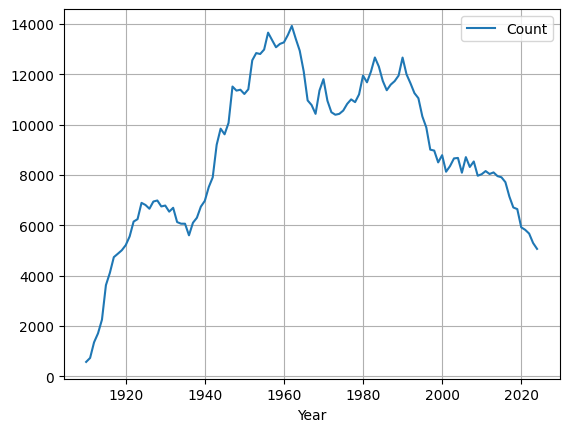

In [7]:
year_counts = df.groupby("Year").sum(numeric_only=True)
year_counts.plot(kind='line')
plt.grid()

In [8]:
# Top 10 most popular baby girl names
df[df["Sex"]=="F"].groupby("Name")[["Count"]].sum().sort_values(by="Count", ascending=False).head(10)

,Count
Name,
Mary,5795
Jennifer,5110
Elizabeth,4568
Patricia,3954
Michelle,3633
Karen,3471
Lisa,3361
Susan,3344
Jessica,3248


In [9]:
# Top 10 most popular baby girl names
(df.groupby(["Sex", "Name"])[["Count"]].sum().reset_index()
    .sort_values(by=["Sex", "Count"], ascending=[True, False])[["Name", "Count"]].head(10))

,Name,Count
1217,Mary,5795
752,Jennifer,5110
483,Elizabeth,4568
1390,Patricia,3954
1263,Michelle,3633
862,Karen,3471
1091,Lisa,3361
1633,Susan,3344
758,Jessica,3248
1088,Linda,3113


In [10]:
# Top 10 most popular baby boy names
df[df["Sex"]=="M"].groupby("Name")[["Count"]].sum().sort_values(by="Count", ascending=False).head(10)

,Count
Name,
Michael,14012
John,12364
Robert,12315
James,12149
David,11162
William,9993
Richard,8793
Joseph,7913
Christopher,6820


In [11]:
# Top 10 most popular baby boy names
(df.groupby(["Sex", "Name"])[["Count"]].sum().reset_index()
    .sort_values(by=["Sex", "Count"], ascending=[False, False])[["Name", "Count"]].head(10))

,Name,Count
2732,Michael,14012
2409,John,12364
2878,Robert,12315
2341,James,12149
2088,David,11162
3126,William,9993
2867,Richard,8793
2423,Joseph,7913
2016,Christopher,6820
2070,Daniel,6559


In [12]:
# Top 10 least popular baby girl names
df[df["Sex"]=="F"].groupby("Name")[["Count"]].sum().sort_values(by="Count").head(10)

,Count
Name,
Alanna,5
Yoko,5
Windy,5
Abcde,5
Abby,5
Celestine,5
Tessa,5
Teruyo,5
Teresita,5


In [13]:
# Top 10 least popular baby girl names
(df.groupby(["Sex", "Name"])[["Count"]].sum().reset_index()
    .sort_values(by=["Sex", "Count"])[["Name", "Count"]].head(10))

,Name,Count
2,Abby,5
3,Abcde,5
13,Adelina,5
16,Adelynn,5
18,Adriane,5
25,Ailana,5
29,Ainsley,5
30,Airi,5
33,Aiyanna,5
35,Akie,5


In [14]:
# Top 10 least popular baby boy names
df[df["Sex"]=="M"].groupby("Name")[["Count"]].sum().sort_values(by="Count").head(10)

,Count
Name,
Zyan,5
Winfred,5
Ammon,5
Aloysius,5
Jacoby,5
Issac,5
Isiah,5
Virgil,5
Jai,5


In [15]:
# Top 10 least popular baby boy names
(df.groupby(["Sex", "Name"])[["Count"]].sum().reset_index()
    .sort_values(by=["Sex", "Count"], ascending=[False, True]).head(10))

,Sex,Name,Count
1823,M,Al,5
1836,M,Alii,5
1842,M,Aloysius,5
1848,M,Ammon,5
1864,M,Ariel,5
1870,M,Asao,5
1875,M,Atreyu,5
1880,M,Augustus,5
1883,M,Austyn,5
1886,M,Axl,5


In [16]:
f_name_counts = df[df["Sex"] == "F"].groupby("Name", as_index=False)["Count"].sum()

min_count = f_name_counts["Count"].min()
print(min_count)
display(f_name_counts[f_name_counts["Count"] == min_count])

5


,Name,Count
2,Abby,5
3,Abcde,5
13,Adelina,5
16,Adelynn,5
18,Adriane,5
...,...,...
1771,Windy,5
1780,Yoko,5
1785,Yoshimi,5
1787,Yui,5


In [17]:
m_name_counts = df[df["Sex"] == "M"].groupby("Name", as_index=False)["Count"].sum()

min_count = m_name_counts["Count"].min()
print(min_count)
display(m_name_counts[m_name_counts["Count"] == min_count])

5


,Name,Count
20,Al,5
33,Alii,5
39,Aloysius,5
45,Ammon,5
61,Ariel,5
...,...,...
1337,Yoshikatsu,5
1341,Yoshitaka,5
1350,Zack,5
1363,Zephyr,5
